pour l'execution du code (amal) : Choisis Jupyter Kernel → Python 3.11 (env_mediapipe)


* pretraitement :
  
   dataset:ASL Alphabet Dataset sur Kaggle
   Les lettres J et Z sont réalisées avec mouvement
   ⚡ Conseil : Commencer avec le dataset Kaggle d’images  statiques, puis plus tard ajouter les séquences J et Z.

   4️⃣ Recommandation pratique pour ton cas
   Lettre A–I, K–Y : 500 images par lettre (donc ~12 000 images)
   J et Z : 50–100 séquences par lettre (10–20 frames par séquence)

   Cela te donne un dataset raisonnable pour un MLP, tout en permettant de gérer J et Z dynamiques.


   ***Filtering = optionnel, dépend de la qualité de ton dataset ,ce n'est pas nessaire dans notre cas car : Dataset propre (Kaggle ASL Alphabet, images bien découpées et nettes

   ***Normalisation et resize = obligatoire





* Extraction des features:(on a choisi MediaPipe)


  HOG/LBP : Travaillent sur les pixels. Si l'arrière-plan change ou si la lumière varie, le modèle échoue.

  MediaPipe : Extrait les coordonnées (x, y, z) des articulations de la main. Le MLP apprend la position des doigts, peu importe la couleur de peau ou le fond. C'est beaucoup plus léger et précis.

  *

# pretraitement :

Parcours chaque lettre A–Z

Sélectionne 500 images aléatoires par lettre

Redimensionne à 64×64 pixels

Convertit BGR → RGB

Applique un Gaussian Blur pour réduire le bruit

Normalise les pixels entre 0 et 1

Sauvegarde en .npy pour un chargement rapide

Sépare 85% train / 15% test :                  
Pour chaque lettre, on prend toutes les images disponibles (ou 500 max)

On mélange aléatoirement les images

On divise 85% pour train et 15% pour test

On sauvegarde dans les sous-dossiers train/lettre et test/lettre  






1️⃣ Mélange des images au niveau global

Dans le code de prétraitement, la division train/test est faite par lettre, donc chaque sous-dossier contient des images triées par classe.

Pour entraîner ton modèle (MLP), on charge toutes les images de tous les sous-dossiers train et on mélange l’ensemble pour créer X_train et y_train.

💡 Pourquoi mélanger ?

Pour éviter que le modèle voie toutes les images d’une classe à la suite → sinon il pourrait apprendre un ordre artificiel au lieu des patterns des lettres.

Le mélange améliore la généralisation.

In [1]:
import cv2
print(cv2.__version__)


4.12.0


In [2]:
import cv2            # Bibliothèque pour manipuler les images
import numpy as np    # Pour manipuler les tableaux numériques
import os             # Pour gérer les fichiers et dossiers
import random         # Pour mélanger les fichiers aléatoirement

# ------------------------------
# Configuration des paramètres
# ------------------------------
LETTERS = "ABCDE"  # Lettres à garder (on ignore SPACE, DELETE, NOTHING)
IMG_SIZE = 64          # Taille de sortie des images
MAX_IMAGES = 500       # Nombre maximum d’images par lettre
RAW_DATA_PATH = r"C:\Users\Hiba\OneDrive\Bureau\projetImgPros\asl_alphabet_train\asl_alphabet_train"
PROCESSED_PATH = r"C:\Users\Hiba\OneDrive\Bureau\projetImgPros\processed_dataset"

# ------------------------------
# Création des dossiers train/test
# ------------------------------
os.makedirs(os.path.join(PROCESSED_PATH, "train"), exist_ok=True)  # Crée dossier train s'il n'existe pas
os.makedirs(os.path.join(PROCESSED_PATH, "test"), exist_ok=True)   # Crée dossier test s'il n'existe pas

# Pour chaque lettre, créer un sous-dossier dans train et test
for l in LETTERS:
    os.makedirs(os.path.join(PROCESSED_PATH, "train", l), exist_ok=True)
    os.makedirs(os.path.join(PROCESSED_PATH, "test", l), exist_ok=True)

# ------------------------------
# Fonction pour traiter et sauvegarder les images
# ------------------------------
def process_and_save(img_list, src_folder, dest_folder):
    """
    img_list : liste des fichiers images à traiter
    src_folder : dossier source de la lettre
    dest_folder : dossier de destination (train/test)
    """
    for img_file in img_list:
        img_path = os.path.join(src_folder, img_file)  # Chemin complet vers l'image
        img = cv2.imread(img_path)                      # Lire l'image
        if img is None:                                 # Vérifier si la lecture a échoué
            continue
        
        # ------------------------------
        # Redimensionner l'image à IMG_SIZE x IMG_SIZE
        # ------------------------------
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        # ------------------------------
        # Conversion BGR (OpenCV) -> RGB
        # ------------------------------
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # ------------------------------
        # Appliquer un filtre Gaussian pour réduire le bruit
        # (kernel 3x3, écart-type 0)
        # ------------------------------
        img = cv2.GaussianBlur(img, (3, 3), 0)
        
        # ------------------------------
        # Normalisation des pixels entre 0 et 1
        # ------------------------------
        img = img / 255.0
        
        # ------------------------------
        # Sauvegarde de l'image traitée au format .npy
        # Cela permet de charger rapidement le dataset plus tard
        # ------------------------------
        save_path = os.path.join(dest_folder, img_file.split(".")[0] + ".npy")
        np.save(save_path, img)

# ------------------------------
# Traitement de toutes les lettres
# ------------------------------
for letter in LETTERS:
    letter_path = os.path.join(RAW_DATA_PATH, letter)  # Chemin du dossier pour la lettre
    if not os.path.exists(letter_path):
        print(f"⚠️ Dossier introuvable : {letter_path}")
        continue

    # Liste tous les fichiers images pour cette lettre
    images = os.listdir(letter_path)
    
    # Mélange aléatoire pour sélectionner des images variées
    random.shuffle(images)
    
    # Limite à MAX_IMAGES pour équilibrer le dataset
    images = images[:MAX_IMAGES]

    # Split 85% train / 15% test
    split_idx = int(len(images) * 0.85)
    train_imgs = images[:split_idx]
    test_imgs = images[split_idx:]

    # Traitement et sauvegarde des images d'entraînement
    process_and_save(train_imgs, letter_path, os.path.join(PROCESSED_PATH, "train", letter))
    
    # Traitement et sauvegarde des images de test
    process_and_save(test_imgs, letter_path, os.path.join(PROCESSED_PATH, "test", letter))

# ------------------------------
# Message final
# ------------------------------
print("✅ Dataset préparé avec 500 images max par lettre et filtrage Gaussian inclus.")


✅ Dataset préparé avec 500 images max par lettre et filtrage Gaussian inclus.


In [3]:
import numpy as np
import os
import random

# ------------------------------
# Configuration des chemins
# ------------------------------
PROCESSED_PATH = r"C:\Users\Hiba\OneDrive\Bureau\projetImgPros\processed_dataset"
LETTERS = "ABCDE"  # Lettres utilisées, J et Z exclues

# ------------------------------
# Initialiser les listes pour stocker les données et labels
# ------------------------------
X_train = []  # Liste pour les images/features d'entraînement
y_train = []  # Liste pour les labels correspondants
X_test = []   # Liste pour les images/features de test
y_test = []   # Liste pour les labels correspondants

# ------------------------------
# Fonction pour charger les fichiers .npy d'un dossier
# ------------------------------
def load_data_from_folder(folder_path, label):
    """
    folder_path : chemin vers le dossier contenant les fichiers .npy
    label : lettre correspondante (A, B, ...)
    retourne : une liste de tableaux numpy
    """
    data = []
    for file in os.listdir(folder_path):
        if file.endswith(".npy"):               # Vérifie que le fichier est bien un .npy
            file_path = os.path.join(folder_path, file)
            img = np.load(file_path)            # Charge le tableau numpy
            data.append(img)                    # Ajoute à la liste
    labels = [label] * len(data)               # Crée une liste de labels identiques pour chaque image
    return data, labels

# ------------------------------
# Charger toutes les lettres pour le train et test
# ------------------------------
for letter in LETTERS:
    # Dossier train pour la lettre
    train_folder = os.path.join(PROCESSED_PATH, "train", letter)
    train_data, train_labels = load_data_from_folder(train_folder, letter)
    X_train.extend(train_data)       # Ajouter toutes les images à X_train
    y_train.extend(train_labels)     # Ajouter tous les labels à y_train

    # Dossier test pour la lettre
    test_folder = os.path.join(PROCESSED_PATH, "test", letter)
    test_data, test_labels = load_data_from_folder(test_folder, letter)
    X_test.extend(test_data)         # Ajouter toutes les images à X_test
    y_test.extend(test_labels)       # Ajouter tous les labels à y_test

# ------------------------------
# Convertir les listes en tableaux numpy pour faciliter le traitement
# ------------------------------
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)



# ------------------------------
# Mélanger les données pour éviter tout ordre artificiel
# ------------------------------
# Mélange conjoint des images et labels pour conserver la correspondance
train_indices = np.arange(len(X_train))
np.random.shuffle(train_indices)
X_train = X_train[train_indices]
y_train = y_train[train_indices]

test_indices = np.arange(len(X_test))
np.random.shuffle(test_indices)
X_test = X_test[test_indices]
y_test = y_test[test_indices]

# ------------------------------
# Vérification
# ------------------------------
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("✅ Données prêtes pour l'entraînement du modèle MLP")

print(y_train[:5])
print(X_train[:5])




X_train shape: (7988, 64, 64, 3)
y_train shape: (7988,)
X_test shape: (1771, 64, 64, 3)
y_test shape: (1771,)
✅ Données prêtes pour l'entraînement du modèle MLP
['C' 'A' 'B' 'B' 'C']
[[[[0.05098039 0.03529412 0.58823529]
   [0.05882353 0.03921569 0.47843137]
   [0.06666667 0.03921569 0.36470588]
   ...
   [0.14901961 0.13333333 0.45490196]
   [0.16078431 0.15686275 0.5372549 ]
   [0.15686275 0.15686275 0.6       ]]

  [[0.07058824 0.04313725 0.4745098 ]
   [0.08627451 0.05098039 0.32941176]
   [0.09803922 0.05098039 0.18823529]
   ...
   [0.20392157 0.19215686 0.3372549 ]
   [0.21176471 0.20784314 0.43137255]
   [0.20392157 0.20392157 0.50196078]]

  [[0.09803922 0.05490196 0.36470588]
   [0.1254902  0.07058824 0.18823529]
   [0.15294118 0.08627451 0.01960784]
   ...
   [0.25490196 0.25882353 0.23529412]
   [0.24705882 0.25882353 0.33333333]
   [0.23921569 0.24705882 0.41176471]]

  ...

  [[0.3372549  0.3372549  0.67058824]
   [0.47058824 0.4745098  0.62352941]
   [0.61176471 0.615686

# Extraction des features:

On va partir de ton X_train et X_test (images déjà prétraitées et normalisées) et extraire 21 landmarks × 3 coordonnées (x, y, z) pour chaque main détectée

In [4]:
import mediapipe as mp
print(mp.__version__)



0.10.10


In [5]:
import mediapipe as mp
import numpy as np

# ------------------------------
# Initialisation Mediapipe Hands
# ------------------------------
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=True,      # True car nous traitons des images fixes
    max_num_hands=1,             # Une seule main par image
    min_detection_confidence=0.5 # Seuil de confiance pour la détection
)

# ------------------------------
# Fonction pour extraire les landmarks d'une image
# ------------------------------
def extract_landmarks(img):
    """
    img : image RGB normalisée (64,64,3)
    retourne : vecteur de 63 valeurs (21 points * 3 coordonnées)
               ou None si main non détectée
    """
    # Mediapipe travaille avec des valeurs uint8 [0-255]
    img_uint8 = (img * 255).astype(np.uint8)
    results = hands.process(img_uint8)

    if results.multi_hand_landmarks:
        hand_landmarks = results.multi_hand_landmarks[0]  # première main détectée
        landmarks = []
        for lm in hand_landmarks.landmark:
            landmarks.extend([lm.x, lm.y, lm.z])  # x, y, z normalisés
        return np.array(landmarks)
    else:
        return None  # main non détectée

# ------------------------------
# Fonction pour transformer un dataset entier
# ------------------------------
def create_landmarks_dataset(X, y):
    X_landmarks = []
    y_landmarks = []

    for i in range(len(X)):
        lm = extract_landmarks(X[i])
        if lm is not None:  # conserver uniquement les images où la main est détectée
            X_landmarks.append(lm)
            y_landmarks.append(y[i])

    return np.array(X_landmarks), np.array(y_landmarks)

# ------------------------------
# Extraire les landmarks pour train et test
# ------------------------------
X_train_lm, y_train_lm = create_landmarks_dataset(X_train, y_train)
X_test_lm, y_test_lm = create_landmarks_dataset(X_test, y_test)

# ------------------------------
# Vérification des shapes
# ------------------------------
print("X_train_lm shape:", X_train_lm.shape)  # (num_images_valide, 63)
print("y_train_lm shape:", y_train_lm.shape)
print("X_test_lm shape:", X_test_lm.shape)
print("y_test_lm shape:", y_test_lm.shape)
print("✅ Landmarks extraits et prêts pour le MLP !")


X_train_lm shape: (4660, 63)
y_train_lm shape: (4660,)
X_test_lm shape: (1045, 63)
y_test_lm shape: (1045,)
✅ Landmarks extraits et prêts pour le MLP !


Exemple labels encodés : [1 1 3 2 1]

⏳ Entraînement du MLP...
Iteration 1, loss = 1.07247772
Validation score: 0.914163
Iteration 2, loss = 0.38376420
Validation score: 0.946352
Iteration 3, loss = 0.23330028
Validation score: 0.961373
Iteration 4, loss = 0.18194833
Validation score: 0.959227
Iteration 5, loss = 0.15647186
Validation score: 0.972103
Iteration 6, loss = 0.13929044
Validation score: 0.974249
Iteration 7, loss = 0.13612428
Validation score: 0.924893
Iteration 8, loss = 0.13300950
Validation score: 0.972103
Iteration 9, loss = 0.11608930
Validation score: 0.978541
Iteration 10, loss = 0.11366750
Validation score: 0.972103
Iteration 11, loss = 0.10652589
Validation score: 0.972103
Iteration 12, loss = 0.11067202
Validation score: 0.967811
Iteration 13, loss = 0.10175792
Validation score: 0.976395
Iteration 14, loss = 0.09293866
Validation score: 0.984979
Iteration 15, loss = 0.08212398
Validation score: 0.976395
Iteration 16, loss = 0.10040774
Validation score: 0.965665
It

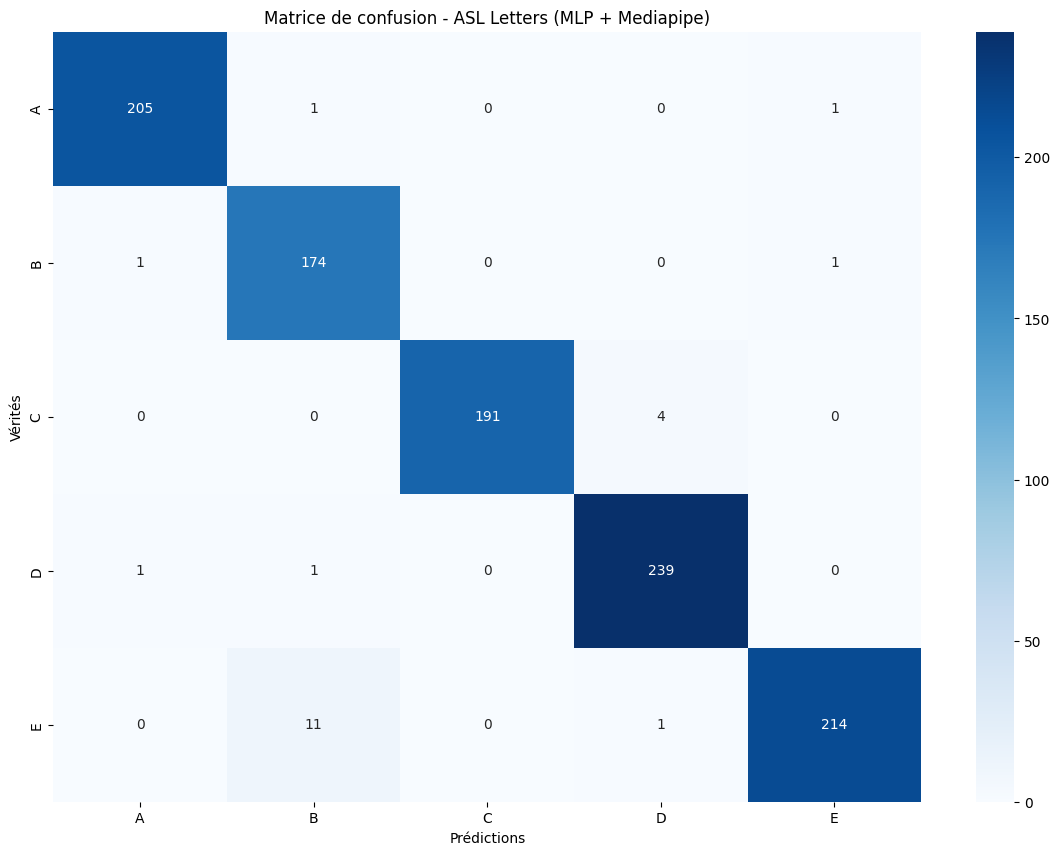


💾 Modèle sauvegardé sous : asl_mlp_model.pkl


In [6]:
# ----------------------------------------------------------
# 1) Importation des bibliothèques
# ----------------------------------------------------------
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
import joblib   # Pour sauvegarder le modèle
import matplotlib.pyplot as plt
import seaborn as sns


# ----------------------------------------------------------
# 3) Encoder les labels (A -> 0, B -> 1, ...)
# ----------------------------------------------------------
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_lm)
y_test_encoded = label_encoder.transform(y_test_lm)

print("Exemple labels encodés :", y_train_encoded[:5])

# ----------------------------------------------------------
# 4) Création du modèle MLP
# ----------------------------------------------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # moins de neurones que 256-128-64
    activation='relu',
    solver='adam',
    max_iter=100,                  # nombre raisonnable d'itérations
    batch_size=16,                  # batch plus petit si peu de données
    early_stopping=True,            # stop automatique si la performance sur validation ne s'améliore plus
    validation_fraction=0.1,        # fraction des données d'entraînement pour valider
    verbose=True
)


# ----------------------------------------------------------
# 5) Entraînement du modèle
# ----------------------------------------------------------
print("\n⏳ Entraînement du MLP...")
mlp.fit(X_train_lm, y_train_encoded)
print("✅ Entraînement terminé !")

# ----------------------------------------------------------
# 6) Prédictions
# ----------------------------------------------------------
y_pred = mlp.predict(X_test_lm)

# ----------------------------------------------------------
# 7) Évaluation
# ----------------------------------------------------------
print("\n📊 Accuracy globale :", accuracy_score(y_test_encoded, y_pred))

print("\n📈 Classification Report :")
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

pcm = confusion_matrix(y_test_encoded, y_pred)
labels = label_encoder.classes_

# Plot
plt.figure(figsize=(14, 10))
sns.heatmap(pcm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion - ASL Letters (MLP + Mediapipe)")
plt.show()

# ----------------------------------------------------------
# 8) Sauvegarde du modèle entraîné
# ----------------------------------------------------------
joblib.dump(mlp, "asl_mlp_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")
print("\n💾 Modèle sauvegardé sous : asl_mlp_model.pkl")


In [1]:
import cv2
import mediapipe as mp
import numpy as np
import joblib
import pyttsx3
import threading
from collections import deque

# =========================================================
# 1) CLASSE POUR LA VOIX (stable + non bloquante)
# =========================================================
class VoiceFeedback:
    def __init__(self, cooldown_frames=8):
        self.buffer = deque(maxlen=cooldown_frames)
        self.last_spoken = None

    def _speak_thread(self, text):
        engine = pyttsx3.init()
        engine.setProperty('rate', 160)
        engine.setProperty('volume', 1.0)
        engine.say(text)
        engine.runAndWait()

    def update_and_maybe_speak(self, letter):
        if letter is None:
            self.buffer.clear()
            return

        self.buffer.append(letter)

        if len(self.buffer) < self.buffer.maxlen:
            return

        # si les 8 dernières lettres sont identiques
        if all(x == letter for x in self.buffer):
            if self.last_spoken == letter:
                return

            t = threading.Thread(target=self._speak_thread, args=(letter,), daemon=True)
            t.start()
            self.last_spoken = letter


voice = VoiceFeedback(cooldown_frames=8)



# =========================================================
# 2) Charger modèle + label encoder
# =========================================================
mlp = joblib.load("asl_mlp_model.pkl")
label_encoder = joblib.load("label_encoder.pkl")



# =========================================================
# 3) Initialisation Mediapipe
# =========================================================
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)



# =========================================================
# 4) Fonction de normalisation → rend ton modèle plus stable
# =========================================================
def normalize_landmarks(landmarks):
    lm = np.array(landmarks)
    lm = lm.reshape(21, 3)

    # centrer sur le poignet
    wrist = lm[0]
    lm -= wrist

    # normaliser la dimension
    max_dist = np.max(np.linalg.norm(lm, axis=1))
    if max_dist > 0:
        lm /= max_dist

    return lm.flatten().reshape(1, -1)



# =========================================================
# 5) Buffer pour stabiliser la lettre BEFORE AFFICHAGE
# =========================================================
prediction_buffer = deque(maxlen=7)



# =========================================================
# 6) Webcam
# =========================================================
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("❌ Webcam inaccessible.")
    exit()

print("✅ Webcam activée — Appuie sur 'q' pour quitter.")



# =========================================================
# 7) BOUCLE PRINCIPALE
# =========================================================
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)

    stable_letter = None

    if results.multi_hand_landmarks:
        hand_landmarks = results.multi_hand_landmarks[0]
        mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

        # extraction
        raw_lm = []
        for lm in hand_landmarks.landmark:
            raw_lm.extend([lm.x, lm.y, lm.z])

        # normalisation améliorée
        landmarks = normalize_landmarks(raw_lm)

        # prédiction
        pred_class = mlp.predict(landmarks)
        pred_label = label_encoder.inverse_transform(pred_class)[0]

        # stabilisation par majorité
        prediction_buffer.append(pred_label)

        if len(prediction_buffer) == prediction_buffer.maxlen:
            # lettre la plus fréquente = lettre stable
            stable_letter = max(set(prediction_buffer), key=prediction_buffer.count)

            cv2.putText(frame, f"Lettre : {stable_letter}", (10, 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.6, (0, 255, 0), 3)

            # 🔊 voix stable
            voice.update_and_maybe_speak(stable_letter)

    else:
        prediction_buffer.clear()

    cv2.imshow("ASL Recognition Improved", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break


cap.release()
cv2.destroyAllWindows()


✅ Webcam activée — Appuie sur 'q' pour quitter.


Exception in thread Thread-4 (_speak_thread):
Traceback (most recent call last):
  File "C:\Users\Hiba\miniconda3\envs\signlang\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "C:\Users\Hiba\miniconda3\envs\signlang\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\Hiba\AppData\Local\Temp\ipykernel_9556\2110155787.py", line 22, in _speak_thread
  File "C:\Users\Hiba\AppData\Roaming\Python\Python310\site-packages\pyttsx3\engine.py", line 219, in runAndWait
    raise RuntimeError(msg)
RuntimeError: run loop already started
Exception in thread Thread-6 (_speak_thread):
Traceback (most recent call last):
  File "C:\Users\Hiba\miniconda3\envs\signlang\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "C:\Users\Hiba\miniconda3\envs\signlang\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\Hiba\AppData\Local\Temp\ipykernel_9556\2110155787.py", line 2

In [8]:
if not cap.isOpened():
    print("❌ Erreur : la webcam ne s'ouvre pas.")
    exit()
else:
    print("✅ Webcam ouverte avec succès.")


❌ Erreur : la webcam ne s'ouvre pas.
